## Tiny CNN


In [ ]:
import os
import wandb
from google.colab import drive, files
import shutil
import pandas as pd

# 1. clone repo only if not already there
%cd /content
if not os.path.exists("/content/ml-assignment-Facial-Expression-Recognition"):
    !git clone https://github.com/Likunach/ml-assignment-Facial-Expression-Recognition.git
%cd /content/ml-assignment-Facial-Expression-Recognition

# 2. install dependencies
!pip install wandb tqdm torch torchvision -q

# 3. mount drive
drive.mount('/content/drive')
os.makedirs('/content/drive/MyDrive/fer2013/checkpoints', exist_ok=True)

# 4. upload csvs
os.makedirs('data', exist_ok=True)
print("Upload train.csv and test.csv:")
uploaded = files.upload()
for filename in uploaded.keys():
    shutil.move(filename, f'data/{filename}')
    print(f'Moved {filename} → data/')

# 5. verify
df = pd.read_csv('data/train.csv')
print(f'train.csv shape: {df.shape}')

# 6. wandb login
wandb.login()
print("All done, ready to train")

/content
/content/ml-assignment-Facial-Expression-Recognition
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Upload train.csv and test.csv:


Saving test.csv to test.csv
Saving train.csv to train.csv
Moved test.csv → data/
Moved train.csv → data/
train.csv shape: (28709, 2)


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: lchit22 (lchit22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


All done, ready to train


#### 1. Setup and Imports

In [ ]:
import sys
import os

print("Current working directory:", os.getcwd())

if os.path.isdir(os.path.join(os.getcwd(), "src")):
    PROJECT_ROOT = os.path.abspath(os.getcwd())
else:
    PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

WANDB_DIR = os.path.join(os.path.expanduser("~"), "wandb_logs", "fer2013")
os.makedirs(WANDB_DIR, exist_ok=True)
os.environ["WANDB_DIR"] = WANDB_DIR
print(f"Wandb dir: {WANDB_DIR}")

import torch
import wandb
from tqdm.notebook import tqdm
from src.dataset import get_dataloaders
from src.models import TinyCNN
from src.utils import generate_run_name, log_confusion_matrix, EarlyStopping, EMOTION_LABELS
from src.train import train

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

wandb.login()
print('Wandb ready')

Current working directory: /content/ml-assignment-Facial-Expression-Recognition
Project root: /content/ml-assignment-Facial-Expression-Recognition
Wandb dir: /root/wandb_logs/fer2013
Using device: cuda
Wandb ready


In [ ]:
os.makedirs('/content/drive/MyDrive/fer2013/checkpoints', exist_ok=True)
os.chdir('/content/ml-assignment-Facial-Expression-Recognition')

# this makes 'checkpoints/' folder point to Drive
import os
os.makedirs('checkpoints', exist_ok=True)

import subprocess
subprocess.run(['ln', '-sfn',
    '/content/drive/MyDrive/fer2013/checkpoints',
    'checkpoints'])
print("checkpoints → Drive linked")

checkpoints → Drive linked


#### 2. Data Loading and Augmentation

In [ ]:
# test all three augmentation modes load correctly
for aug in ['none', 'light', 'strong']:
    train_loader, val_loader, test_loader = get_dataloaders(
        data_dir='data',
        aug_mode=aug,
        batch_size=64
    )
    images, labels = next(iter(train_loader))
    print(f'aug={aug} | batch shape: {images.shape} | labels shape: {labels.shape}')

print('Data loading works correctly')

aug=none | batch shape: torch.Size([64, 1, 48, 48]) | labels shape: torch.Size([64])
aug=light | batch shape: torch.Size([64, 1, 48, 48]) | labels shape: torch.Size([64])
aug=strong | batch shape: torch.Size([64, 1, 48, 48]) | labels shape: torch.Size([64])
Data loading works correctly


#### 3. Model Definition

In [ ]:
# verify model builds and forward pass works
model = TinyCNN(dropout=0.0)
dummy = torch.randn(4, 1, 48, 48)
out = model(dummy)
print(f'TinyCNN output shape: {out.shape}')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

TinyCNN output shape: torch.Size([4, 7])
Total parameters: 595,655


#### 4. Hyperparameter Setup

In [ ]:
CONFIGS = [
    # ── learning rate sweep (adam, no aug, no dropout) ──
    {'run_name': 'tiny_adam_0.01_bs64_noaug_do0',    'lr': 0.01,   'optimizer': 'adam', 'batch_size': 64, 'aug': 'none',  'dropout': 0.0, 'epochs': 15},
    {'run_name': 'tiny_adam_0.001_bs64_noaug_do0',   'lr': 0.001,  'optimizer': 'adam', 'batch_size': 64, 'aug': 'none',  'dropout': 0.0, 'epochs': 15},
    {'run_name': 'tiny_adam_0.0003_bs64_noaug_do0',  'lr': 0.0003, 'optimizer': 'adam', 'batch_size': 64, 'aug': 'none',  'dropout': 0.0, 'epochs': 15},
    {'run_name': 'tiny_adam_0.0001_bs64_noaug_do0',  'lr': 0.0001, 'optimizer': 'adam', 'batch_size': 64, 'aug': 'none',  'dropout': 0.0, 'epochs': 15},

    # ── optimizer comparison ──
    {'run_name': 'tiny_sgd_0.01_bs64_noaug_do0',     'lr': 0.01,   'optimizer': 'sgd',  'batch_size': 64, 'aug': 'none',  'dropout': 0.0, 'epochs': 15},
    {'run_name': 'tiny_sgd_0.001_bs64_noaug_do0',    'lr': 0.001,  'optimizer': 'sgd',  'batch_size': 64, 'aug': 'none',  'dropout': 0.0, 'epochs': 15},

    # ── augmentation effect ──
    {'run_name': 'tiny_adam_0.001_bs64_light_do0',   'lr': 0.001,  'optimizer': 'adam', 'batch_size': 64, 'aug': 'light', 'dropout': 0.0, 'epochs': 15},
    {'run_name': 'tiny_adam_0.001_bs64_strong_do0',  'lr': 0.001,  'optimizer': 'adam', 'batch_size': 64, 'aug': 'strong','dropout': 0.0, 'epochs': 15},

    # ── dropout effect ──
    {'run_name': 'tiny_adam_0.001_bs64_noaug_do0.25','lr': 0.001,  'optimizer': 'adam', 'batch_size': 64, 'aug': 'none',  'dropout': 0.25,'epochs': 15},
    {'run_name': 'tiny_adam_0.001_bs64_noaug_do0.5', 'lr': 0.001,  'optimizer': 'adam', 'batch_size': 64, 'aug': 'none',  'dropout': 0.5, 'epochs': 15},

    # ── batch size effect ──
    {'run_name': 'tiny_adam_0.001_bs32_noaug_do0',   'lr': 0.001,  'optimizer': 'adam', 'batch_size': 32, 'aug': 'none',  'dropout': 0.0, 'epochs': 15},
    {'run_name': 'tiny_adam_0.001_bs128_noaug_do0',  'lr': 0.001,  'optimizer': 'adam', 'batch_size': 128,'aug': 'none',  'dropout': 0.0, 'epochs': 15},
]

print(f'Total runs planned: {len(CONFIGS)}')

Total runs planned: 12


#### 5. Training

In [ ]:
import os

if "WANDB_DIR" not in globals():
    WANDB_DIR = os.path.join(os.path.expanduser("~"), "wandb_logs", "fer2013")
    os.makedirs(WANDB_DIR, exist_ok=True)

all_results = []

for i, config in enumerate(CONFIGS):
    config['arch'] = 'tiny'

    print(f'\n[{i+1}/{len(CONFIGS)}] Starting run: {config["run_name"]}')

    train_loader, val_loader, _ = get_dataloaders(
        data_dir='data',
        aug_mode=config['aug'],
        batch_size=config['batch_size']
    )

    model = TinyCNN(dropout=config['dropout'])

    wandb.init(
        project='fer2013-expression-recognition',
        name=config['run_name'],
        group=config['arch'],
        config=config,
        dir=WANDB_DIR,
    )

    best_val_acc = train(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        config=config,
        device=DEVICE
    )

    wandb.finish()

    all_results.append({
        'run': config['run_name'],
        'best_val_acc': best_val_acc
    })

    print(f'Done [{i+1}/{len(CONFIGS)}] — best_val_acc: {best_val_acc:.4f}')

print('\nAll TinyCNN runs complete')

In [ ]:
import wandb

api = wandb.Api()

# Change this if your entity is different
entity = "lchit22-free-university-of-tbilisi-"
project = "fer2013-expression-recognition"

runs = api.runs(f"{entity}/{project}")

finished_runs = []
running_or_failed = []

for run in runs:
    if run.state == "finished":
        finished_runs.append(run)
    else:
        running_or_failed.append(run)

print("Total runs:", len(runs))
print("Finished runs:", len(finished_runs))
print("Not finished / failed / crashed:", len(running_or_failed))

print("\nFinished run names:")
for run in finished_runs:
    print("-", run.name)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: WARNING Invalid choice


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Total runs: 12
Finished runs: 12
Not finished / failed / crashed: 0

Finished run names:
- tiny_adam_0.01_bs64_noaug_do0
- tiny_adam_0.001_bs64_noaug_do0
- tiny_adam_0.0003_bs64_noaug_do0
- tiny_adam_0.0001_bs64_noaug_do0
- tiny_sgd_0.01_bs64_noaug_do0
- tiny_sgd_0.001_bs64_noaug_do0
- tiny_adam_0.001_bs64_light_do0
- tiny_adam_0.001_bs64_strong_do0
- tiny_adam_0.001_bs64_noaug_do0.25
- tiny_adam_0.001_bs64_noaug_do0.5
- tiny_adam_0.001_bs32_noaug_do0
- tiny_adam_0.001_bs128_noaug_do0


In [5]:
import wandb

api = wandb.Api()

runs = api.runs(
    "lchit22-free-university-of-tbilisi-/fer2013-expression-recognition",
    filters={"group": "tiny"}   # or "TinyCNN" if your group was named TinyCNN
)

all_results = []

for run in runs:
    all_results.append({
        "run": run.name,
        "state": run.state,
        "best_val_acc": run.summary.get("best_val_acc", run.summary.get("val_acc", 0))
    })

    print(
        f'{run.name} | state={run.state} | '
        f'val_acc={run.summary.get("val_acc", 0):.4f} | '
        f'best_val_acc={run.summary.get("best_val_acc", run.summary.get("val_acc", 0)):.4f}'
    )

print(f"\nLoaded {len(all_results)} runs from Wandb")

tiny_adam_0.01_bs64_noaug_do0 | state=finished | val_acc=0.4002 | best_val_acc=0.4002
tiny_adam_0.001_bs64_noaug_do0 | state=finished | val_acc=0.5131 | best_val_acc=0.5131
tiny_adam_0.0003_bs64_noaug_do0 | state=finished | val_acc=0.5193 | best_val_acc=0.5193
tiny_adam_0.0001_bs64_noaug_do0 | state=finished | val_acc=0.4699 | best_val_acc=0.4699
tiny_sgd_0.01_bs64_noaug_do0 | state=finished | val_acc=0.5000 | best_val_acc=0.5000
tiny_sgd_0.001_bs64_noaug_do0 | state=finished | val_acc=0.4439 | best_val_acc=0.4439
tiny_adam_0.001_bs64_light_do0 | state=finished | val_acc=0.5512 | best_val_acc=0.5512
tiny_adam_0.001_bs64_strong_do0 | state=finished | val_acc=0.5141 | best_val_acc=0.5141
tiny_adam_0.001_bs64_noaug_do0.25 | state=finished | val_acc=0.5352 | best_val_acc=0.5352
tiny_adam_0.001_bs64_noaug_do0.5 | state=finished | val_acc=0.5176 | best_val_acc=0.5176
tiny_adam_0.001_bs32_noaug_do0 | state=finished | val_acc=0.5120 | best_val_acc=0.5120
tiny_adam_0.001_bs128_noaug_do0 | state

                              run    state  best_val_acc
   tiny_adam_0.001_bs64_light_do0 finished      0.551202
tiny_adam_0.001_bs64_noaug_do0.25 finished      0.535179
  tiny_adam_0.001_bs128_noaug_do0 finished      0.525601
  tiny_adam_0.0003_bs64_noaug_do0 finished      0.519331
 tiny_adam_0.001_bs64_noaug_do0.5 finished      0.517590
  tiny_adam_0.001_bs64_strong_do0 finished      0.514107
   tiny_adam_0.001_bs64_noaug_do0 finished      0.513062
   tiny_adam_0.001_bs32_noaug_do0 finished      0.512017
     tiny_sgd_0.01_bs64_noaug_do0 finished      0.500000
  tiny_adam_0.0001_bs64_noaug_do0 finished      0.469871
    tiny_sgd_0.001_bs64_noaug_do0 finished      0.443922
    tiny_adam_0.01_bs64_noaug_do0 finished      0.400209


wandb: Currently logged in as: lchit22 (lchit22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


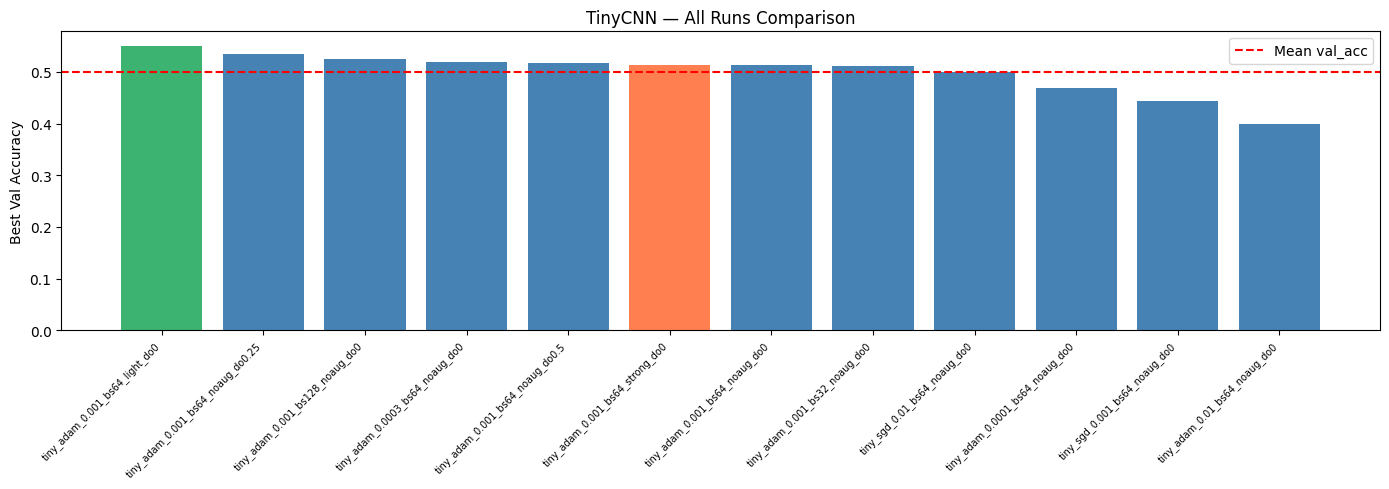

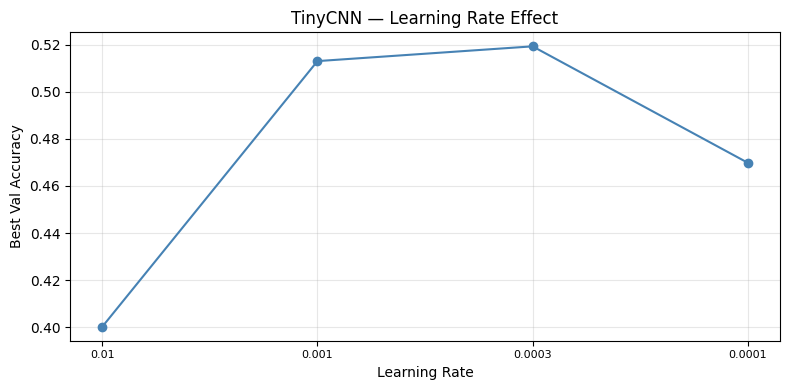

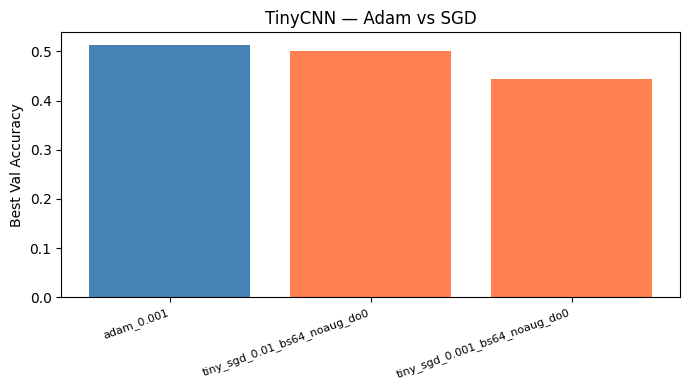

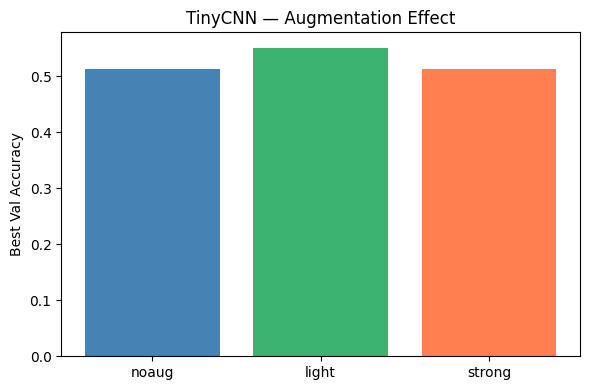

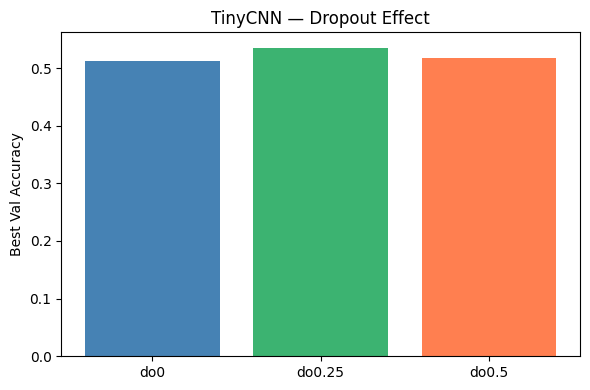


Best run: tiny_adam_0.001_bs64_light_do0
Best val_acc: 0.5512
All charts saved and logged to Wandb


In [7]:
import os

if "WANDB_DIR" not in globals():
    WANDB_DIR = os.path.join(os.path.expanduser("~"), "wandb_logs", "fer2013")
    os.makedirs(WANDB_DIR, exist_ok=True)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results_df = pd.DataFrame(all_results).sort_values('best_val_acc', ascending=False)
print(results_df.to_string(index=False))

# ── Chart 1: Bar chart of all runs ──
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['steelblue' if 'do0' in r and 'noaug' in r
          else 'coral' if 'strong' in r
          else 'mediumseagreen' for r in results_df['run']]
ax.bar(results_df['run'], results_df['best_val_acc'], color=colors)
ax.axhline(y=results_df['best_val_acc'].mean(), color='red', linestyle='--', label='Mean val_acc')
ax.set_xticks(range(len(results_df)))
ax.set_xticklabels(results_df['run'], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Best Val Accuracy')
ax.set_title('TinyCNN — All Runs Comparison')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'tinycnn_bar.png'))
wandb.init(project='fer2013-expression-recognition', name='tinycnn_analysis', group='tiny', job_type='analysis', dir=WANDB_DIR)
wandb.log({'tinycnn_bar_chart': wandb.Image(fig)})
plt.show()

# ── Chart 2: LR effect ──
lr_runs = [r for r in all_results if 'sgd' not in r['run']
           and 'bs32' not in r['run'] and 'bs128' not in r['run']
           and 'do0.25' not in r['run'] and 'do0.5' not in r['run']
           and 'light' not in r['run'] and 'strong' not in r['run']]
lr_df = pd.DataFrame(lr_runs)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(lr_df)), lr_df['best_val_acc'], 'o-', color='steelblue')
ax.set_xticks(range(len(lr_df)))
ax.set_xticklabels([r['run'].split('_')[2] for r in lr_runs], fontsize=8)
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Best Val Accuracy')
ax.set_title('TinyCNN — Learning Rate Effect')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'tinycnn_lr.png'))
wandb.log({'tinycnn_lr_effect': wandb.Image(fig)})
plt.show()

# ── Chart 3: Adam vs SGD ──
adam_acc = next(r['best_val_acc'] for r in all_results if r['run'] == 'tiny_adam_0.001_bs64_noaug_do0')
sgd_runs = [r for r in all_results if 'sgd' in r['run']]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    ['adam_0.001'] + [r['run'] for r in sgd_runs],
    [adam_acc] + [r['best_val_acc'] for r in sgd_runs],
    color=['steelblue', 'coral', 'coral']
)
ax.set_ylabel('Best Val Accuracy')
ax.set_title('TinyCNN — Adam vs SGD')
plt.xticks(rotation=20, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'tinycnn_optimizer.png'))
wandb.log({'tinycnn_optimizer_comparison': wandb.Image(fig)})
plt.show()

# ── Chart 4: Augmentation effect ──
aug_data = [
    ('noaug',  next(r['best_val_acc'] for r in all_results if r['run'] == 'tiny_adam_0.001_bs64_noaug_do0')),
    ('light',  next(r['best_val_acc'] for r in all_results if r['run'] == 'tiny_adam_0.001_bs64_light_do0')),
    ('strong', next(r['best_val_acc'] for r in all_results if r['run'] == 'tiny_adam_0.001_bs64_strong_do0')),
]
aug_labels, aug_vals = zip(*aug_data)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(aug_labels, aug_vals, color=['steelblue', 'mediumseagreen', 'coral'])
ax.set_ylabel('Best Val Accuracy')
ax.set_title('TinyCNN — Augmentation Effect')
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'tinycnn_augmentation.png'))
wandb.log({'tinycnn_augmentation_effect': wandb.Image(fig)})
plt.show()

# ── Chart 5: Dropout effect ──
dropout_data = [
    ('do0',    next(r['best_val_acc'] for r in all_results if r['run'] == 'tiny_adam_0.001_bs64_noaug_do0')),
    ('do0.25', next(r['best_val_acc'] for r in all_results if r['run'] == 'tiny_adam_0.001_bs64_noaug_do0.25')),
    ('do0.5',  next(r['best_val_acc'] for r in all_results if r['run'] == 'tiny_adam_0.001_bs64_noaug_do0.5')),
]
do_labels, do_vals = zip(*dropout_data)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(do_labels, do_vals, color=['steelblue', 'mediumseagreen', 'coral'])
ax.set_ylabel('Best Val Accuracy')
ax.set_title('TinyCNN — Dropout Effect')
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'tinycnn_dropout.png'))
wandb.log({'tinycnn_dropout_effect': wandb.Image(fig)})
plt.show()

wandb.finish()

print(f'\nBest run: {results_df.iloc[0]["run"]}')
print(f'Best val_acc: {results_df.iloc[0]["best_val_acc"]:.4f}')
print('All charts saved and logged to Wandb')